# **1. LIBRARY IMPORTING**

In [1]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import recall_score, confusion_matrix
from keras.saving import load_model
from keras.losses import BinaryCrossentropy

# **2. WITH vs WITHOUT CONVEX HULL**

In [2]:
img_size = 128

## **2.1. Data Loading**

In [3]:
cxrs_ch0 = np.load('/kaggle/input/lung-segmentation-dataset-ch0/without_convexhull/cxrs')
masks_ch0 = np.load('/kaggle/input/lung-segmentation-dataset-ch0/without_convexhull/masks')

print(np.shape(cxrs_ch0))
print(np.shape(masks_ch0))

cxrs_ch1 = np.load('/kaggle/input/lung-segmentation-dataset-ch0/with_convexhull/cxrs')
masks_ch1 = np.load('/kaggle/input/lung-segmentation-dataset-ch0/with_convexhull/masks')

print(np.shape(cxrs_ch1))
print(np.shape(masks_ch1))

(704, 128, 128)
(704, 128, 128)
(704, 128, 128)
(704, 128, 128)


## **2.2. Data Normalization**

In [4]:
cxrs_ch0 = cxrs_ch0.reshape(-1, img_size, img_size, 1)
cxrs_ch0 = cxrs_ch0 / 255

masks_ch0 = masks_ch0.reshape(-1, img_size, img_size, 1)
masks_ch0 = np.array(masks_ch0 / 255, dtype=int)

print(np.shape(cxrs_ch0))
print(np.shape(masks_ch0))

cxrs_ch1 = cxrs_ch1.reshape(-1, img_size, img_size, 1)
cxrs_ch1 = cxrs_ch1 / 255

masks_ch1 = masks_ch1.reshape(-1, img_size, img_size, 1)
masks_ch1 = np.array(masks_ch1 / 255, dtype=int)

print(np.shape(cxrs_ch1))
print(np.shape(masks_ch1))

(704, 128, 128, 1)
(704, 128, 128, 1)
(704, 128, 128, 1)
(704, 128, 128, 1)


## **2.3. Segmentation Models Loading**

In [5]:
unet_ch0 = load_model('/kaggle/input/unet/keras/default/6/Unet.h5')
unet_ch0.summary()

Model: "unet_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 1)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down0_0 (Conv2D)     │ (None, 128, 128, 16)   │            160 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down0_0_activation   │ (None, 128, 128, 16)   │              0 │ unet_down0_0[0][0]     │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down0_1 (Conv2D)     │ (None, 128, 128, 16)   │          2,320 │ unet_down0_0_activati… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down0_1_activation   │ (None, 128, 128, 16)   │              0 │ unet_down0_1[0][0]     │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down1_encode_maxpool │ (None, 64, 64, 16)     │              0 │ unet_down0_1_activati… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down1_conv_0         │ (None, 64, 64, 32)     │          4,640 │ unet_down1_encode_max… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down1_conv_0_activa… │ (None, 64, 64, 32)     │              0 │ unet_down1_conv_0[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down1_conv_1         │ (None, 64, 64, 32)     │          9,248 │ unet_down1_conv_0_act… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down1_conv_1_activa… │ (None, 64, 64, 32)     │              0 │ unet_down1_conv_1[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down2_encode_maxpool │ (None, 32, 32, 32)     │              0 │ unet_down1_conv_1_act… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down2_conv_0         │ (None, 32, 32, 64)     │         18,496 │ unet_down2_encode_max… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down2_conv_0_activa… │ (None, 32, 32, 64)     │              0 │ unet_down2_conv_0[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down2_conv_1         │ (None, 32, 32, 64)     │         36,928 │ unet_down2_conv_0_act… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 2,158,419 (8.23 MB)

 Trainable params: 2,158,417 (8.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [6]:
unet_ch1 = load_model('/kaggle/input/unet/keras/default/7/Unet.h5')
unet_ch1.summary()

Model: "unet_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 1)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down0_0 (Conv2D)     │ (None, 128, 128, 16)   │            160 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down0_0_activation   │ (None, 128, 128, 16)   │              0 │ unet_down0_0[0][0]     │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down0_1 (Conv2D)     │ (None, 128, 128, 16)   │          2,320 │ unet_down0_0_activati… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down0_1_activation   │ (None, 128, 128, 16)   │              0 │ unet_down0_1[0][0]     │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down1_encode_maxpool │ (None, 64, 64, 16)     │              0 │ unet_down0_1_activati… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down1_conv_0         │ (None, 64, 64, 32)     │          4,640 │ unet_down1_encode_max… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down1_conv_0_activa… │ (None, 64, 64, 32)     │              0 │ unet_down1_conv_0[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down1_conv_1         │ (None, 64, 64, 32)     │          9,248 │ unet_down1_conv_0_act… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down1_conv_1_activa… │ (None, 64, 64, 32)     │              0 │ unet_down1_conv_1[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down2_encode_maxpool │ (None, 32, 32, 32)     │              0 │ unet_down1_conv_1_act… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down2_conv_0         │ (None, 32, 32, 64)     │         18,496 │ unet_down2_encode_max… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down2_conv_0_activa… │ (None, 32, 32, 64)     │              0 │ unet_down2_conv_0[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down2_conv_1         │ (None, 32, 32, 64)     │         36,928 │ unet_down2_conv_0_act… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 2,158,419 (8.23 MB)

 Trainable params: 2,158,417 (8.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

## **2.4. Masks Prediction**

In [7]:
def predict_mask(model, cxrs):
    masks_pred = model.predict(cxrs, verbose=True)
    return masks_pred

In [8]:
masks_unet_ch0 = predict_mask(unet_ch0, cxrs_ch0)
print(np.shape(masks_unet_ch0))

masks_unet_ch1 = predict_mask(unet_ch1, cxrs_ch1)
print(np.shape(masks_unet_ch1))

22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step
(704, 128, 128, 1)
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 998ms/step
(704, 128, 128, 1)


## **2.5. Dice, IoU and Loss**

In [9]:
def dice_coef(y_true, y_pred):
    y_pred = np.array(y_pred >= 0.5)
    dice = 0
    for i in range(np.shape(y_true)[0]):
        intersection = np.sum(y_true[i] & y_pred[i])
        combination = np.sum(y_true[i]) + np.sum(y_pred[i])
        dice += intersection * 2 / combination
    mean_dice = dice / np.shape(y_true)[0]
    return mean_dice

In [10]:
def iou_coef(y_true, y_pred):
    y_pred = np.array(y_pred >= 0.5)
    iou = 0
    for i in range(np.shape(y_true)[0]):
        intersection = np.sum(y_true[i] & y_pred[i])
        union = np.sum(y_true[i] | y_pred[i])
        iou += intersection / union
    mean_iou = iou / np.shape(y_true)[0]
    return mean_iou

In [11]:
def bce_loss(y_true, y_pred):
    bce = BinaryCrossentropy(from_logits=False)
    return float(bce(y_true, y_pred))

In [12]:
dice_unet_ch0 = dice_coef(masks_ch0, masks_unet_ch0)
iou_unet_ch0 = iou_coef(masks_ch0, masks_unet_ch0)
loss_unet_ch0 = bce_loss(masks_ch0, masks_unet_ch0)
print('Without Convex Hull:')
print('   dice = {}'.format(dice_unet_ch0))
print('   iou = {}'.format(iou_unet_ch0))
print('   loss = {}'.format(loss_unet_ch0))

dice_unet_ch1 = dice_coef(masks_ch1, masks_unet_ch1)
iou_unet_ch1 = iou_coef(masks_ch1, masks_unet_ch1)
loss_unet_ch1 = bce_loss(masks_ch1, masks_unet_ch1)
print('\nWith Convex Hull:')
print('   dice = {}'.format(dice_unet_ch1))
print('   iou = {}'.format(iou_unet_ch1))
print('   loss = {}'.format(loss_unet_ch1))

Without Convex Hull:
   dice = 0.9625597177797887
   iou = 0.9289749172009529
   loss = 0.09246086329221725

With Convex Hull:
   dice = 0.9783915943586002
   iou = 0.9581260059521847
   loss = 0.08893969655036926


## **2.6. Recall**

In [13]:
sz = np.shape(masks_ch0)[0]
masks_flatten = masks_ch0.reshape(sz, -1)
masks_unet_ch0_flatten = (masks_unet_ch0 >= 0.5).reshape(sz, -1)
masks_unet_ch1_flatten = (masks_unet_ch1 >= 0.5).reshape(sz, -1)

print(np.shape(masks_flatten))
print(np.shape(masks_unet_ch0_flatten))
print(np.shape(masks_unet_ch1_flatten))

(704, 16384)
(704, 16384)
(704, 16384)


In [14]:
def average_recall(y_true, y_pred):
    sum_recall = 0.0
    for i in range(np.shape(y_true)[0]):
        sum_recall += recall_score(y_true[i], y_pred[i])
    return sum_recall / np.shape(y_true)[0]

In [15]:
print('Without Convex Hull:')
print('  Average Recall = {}'.format(average_recall(masks_flatten, masks_unet_ch0_flatten)))
print('\nWith Convex Hull:')
print('  Average Recall = \033[1m{}\033[0m'.format(average_recall(masks_flatten, masks_unet_ch1_flatten)))

Without Convex Hull:
  Average Recall = 0.9624990529324097

With Convex Hull:
  Average Recall = 0.9985007647810559


In [16]:
def min_max_recall(y_true, y_pred):
    recall = np.zeros(np.shape(y_true)[0])
    for i in range(np.shape(y_true)[0]):
        recall[i] = recall_score(y_true[i], y_pred[i])

    return recall.min(), recall.argmin(), recall.max(), recall.argmax()

In [17]:
min_recall_unet, argmin_recall_unet, max_recall_unet, argmax_recall_unet = min_max_recall(masks_flatten, masks_unet_ch0_flatten)
new_min_recall = recall_score(masks_flatten[argmin_recall_unet], masks_unet_ch1_flatten[argmin_recall_unet])
new_max_recall = recall_score(masks_flatten[argmax_recall_unet], masks_unet_ch1_flatten[argmax_recall_unet])

print('Without Convex Hull:')
print('   Min Recall = {} at index {}'.format(round(min_recall_unet, 4), argmin_recall_unet))
print('   Max Recall = {} at index {}'.format(round(max_recall_unet, 4), argmax_recall_unet))

print('\nWith Convex Hull:')
print('   Recall = {} at index {}'.format(round(new_min_recall, 4), argmin_recall_unet))
print('   Recall = {} at index {}'.format(round(new_max_recall, 4), argmax_recall_unet))

Without Convex Hull:
   Min Recall = 0.7181 at index 290
   Max Recall = 0.9994 at index 484

With Convex Hull:
   Recall = 0.9752 at index 290
   Recall = 1.0 at index 484


## **2.7. Visualization**

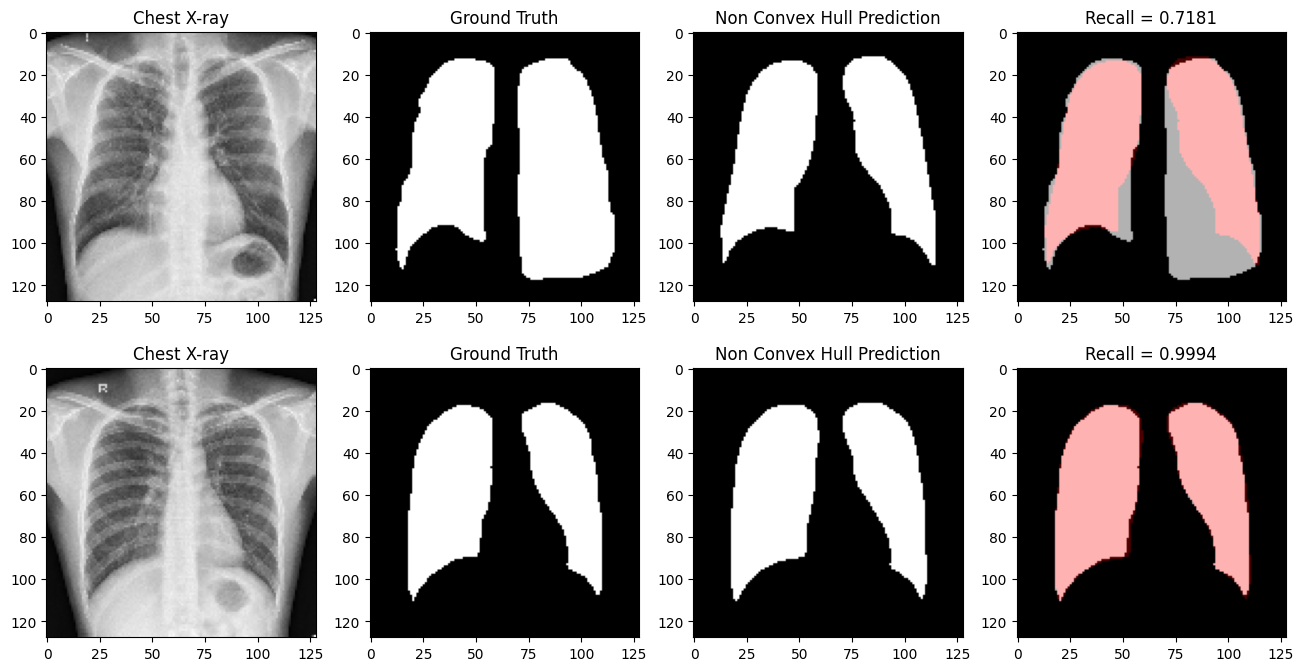

In [18]:
!rm -rf /kaggle/working/*

def save_result(path, image, mask, pred, name):
    image = (image * 255).astype(np.uint8)
    save_path = os.path.join(path, name + '_image.png')
    cv2.imwrite(save_path, image)
    
    mask = (mask * 255).astype(np.uint8)
    save_path = os.path.join(path, name + '_mask.png')
    cv2.imwrite(save_path, mask)

    pred = ((pred >= 0.5) * 255).astype(np.uint8)
    save_path = os.path.join(path, name + '_pred.png')
    cv2.imwrite(save_path, pred)

def read_result(path, name):
    read_path = os.path.join(path, name + '_image.png')
    image = cv2.imread(read_path)
    
    read_path = os.path.join(path, name + '_mask.png')
    mask = cv2.imread(read_path)
    
    read_path = os.path.join(path, name + '_pred.png')
    pred = cv2.imread(read_path)
    
    return image, mask, pred

def diff_mask(ref_image, mask_image):
    mask_image_gray = cv2.cvtColor(mask_image, cv2.COLOR_BGR2GRAY)
    
    mask = cv2.bitwise_and(mask_image, mask_image, mask=mask_image_gray)
    
    mask_coord = np.where(mask!=[0,0,0])

    mask[mask_coord[0],mask_coord[1],:]=[255,0,0]

    ret = cv2.addWeighted(ref_image, 0.7, mask, 0.3, 0)
    return ret

fig, axs = plt.subplots(2, 4, figsize=(16, 8))

idx = argmin_recall_unet
save_result('/kaggle/working/', cxrs_ch0[idx], masks_ch0[idx], masks_unet_ch0[idx], str(idx))
image, mask, pred = read_result('/kaggle/working/', str(idx))
axs[0, 0].set_title('Chest X-ray')
axs[0, 0].imshow(image, cmap='gray')
axs[0, 1].set_title('Ground Truth')
axs[0, 1].imshow(mask, cmap='gray')
axs[0, 2].set_title('Non Convex Hull Prediction')
axs[0, 2].imshow(pred, cmap='gray')
axs[0, 3].set_title('Recall = {}'.format(round(min_recall_unet, 4)))
axs[0, 3].imshow(diff_mask(mask, pred), cmap='gray')

idx = argmax_recall_unet
save_result('/kaggle/working/', cxrs_ch0[idx], masks_ch0[idx], masks_unet_ch0[idx], str(idx))
image, mask, pred = read_result('/kaggle/working/', str(idx))
axs[1, 0].set_title('Chest X-ray')
axs[1, 0].imshow(image, cmap='gray')
axs[1, 1].set_title('Ground Truth')
axs[1, 1].imshow(mask, cmap='gray')
axs[1, 2].set_title('Non Convex Hull Prediction')
axs[1, 2].imshow(pred, cmap='gray')
axs[1, 3].set_title('Recall = {}'.format(round(max_recall_unet, 4)))
axs[1, 3].imshow(diff_mask(mask, pred), cmap='gray')

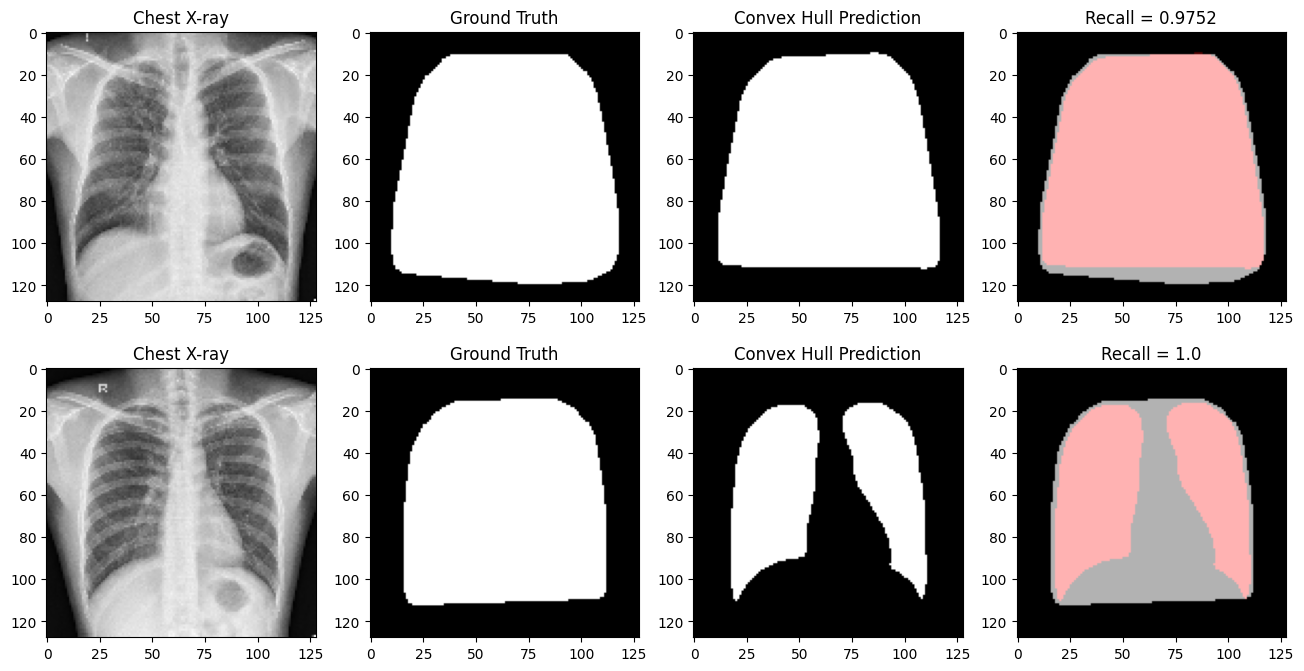

In [19]:
!rm -rf /kaggle/working/*

def save_result(path, image, mask, pred, name):
    image = (image * 255).astype(np.uint8)
    save_path = os.path.join(path, name + '_image.png')
    cv2.imwrite(save_path, image)
    
    mask = (mask * 255).astype(np.uint8)
    save_path = os.path.join(path, name + '_mask.png')
    cv2.imwrite(save_path, mask)

    pred = ((pred >= 0.5) * 255).astype(np.uint8)
    save_path = os.path.join(path, name + '_pred.png')
    cv2.imwrite(save_path, pred)

def read_result(path, name):
    read_path = os.path.join(path, name + '_image.png')
    image = cv2.imread(read_path)
    
    read_path = os.path.join(path, name + '_mask.png')
    mask = cv2.imread(read_path)
    
    read_path = os.path.join(path, name + '_pred.png')
    pred = cv2.imread(read_path)
    
    return image, mask, pred

def diff_mask(ref_image, mask_image):
    mask_image_gray = cv2.cvtColor(mask_image, cv2.COLOR_BGR2GRAY)
    
    mask = cv2.bitwise_and(mask_image, mask_image, mask=mask_image_gray)
    
    mask_coord = np.where(mask!=[0,0,0])

    mask[mask_coord[0],mask_coord[1],:]=[255,0,0]

    ret = cv2.addWeighted(ref_image, 0.7, mask, 0.3, 0)
    return ret

fig, axs = plt.subplots(2, 4, figsize=(16, 8))

idx = argmin_recall_unet
save_result('/kaggle/working/', cxrs_ch0[idx], masks_ch1[idx], masks_unet_ch1[idx], str(idx))
image, mask, pred = read_result('/kaggle/working/', str(idx))
axs[0, 0].set_title('Chest X-ray')
axs[0, 0].imshow(image, cmap='gray')
axs[0, 1].set_title('Ground Truth')
axs[0, 1].imshow(mask, cmap='gray')
axs[0, 2].set_title('Convex Hull Prediction')
axs[0, 2].imshow(pred, cmap='gray')
axs[0, 3].set_title('Recall = {}'.format(round(new_min_recall, 4)))
axs[0, 3].imshow(diff_mask(mask, pred), cmap='gray')

idx = argmax_recall_unet
save_result('/kaggle/working/', cxrs_ch0[idx], masks_ch1[idx], masks_unet_ch0[idx], str(idx))
image, mask, pred = read_result('/kaggle/working/', str(idx))
axs[1, 0].set_title('Chest X-ray')
axs[1, 0].imshow(image, cmap='gray')
axs[1, 1].set_title('Ground Truth')
axs[1, 1].imshow(mask, cmap='gray')
axs[1, 2].set_title('Convex Hull Prediction')
axs[1, 2].imshow(pred, cmap='gray')
axs[1, 3].set_title('Recall = {}'.format(round(new_max_recall, 4)))
axs[1, 3].imshow(diff_mask(mask, pred), cmap='gray')

## **2.8. Confusion Matrix**

In [20]:
negative, positive = 0, 0
TP, TN, FP, FN = 0, 0, 0, 0
for i in range(16384):
    if masks_flatten[argmin_recall_unet][i] == 0:
        negative += 1
    else:
        positive += 1

    if masks_flatten[argmin_recall_unet][i] == 1 and masks_unet_ch0_flatten[argmin_recall_unet][i] == 1:
        TP += 1
    elif masks_flatten[argmin_recall_unet][i] == 1 and masks_unet_ch0_flatten[argmin_recall_unet][i] == 0:
        FN += 1
    elif masks_flatten[argmin_recall_unet][i] == 0 and masks_unet_ch0_flatten[argmin_recall_unet][i] == 0:
        TN += 1
    else:
        FP += 1

print(negative, positive)
print(TP, TN, FP, FN)

9331 7053
5065 9262 69 1988


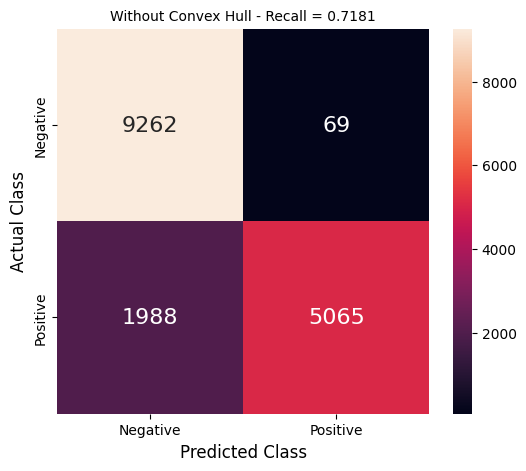

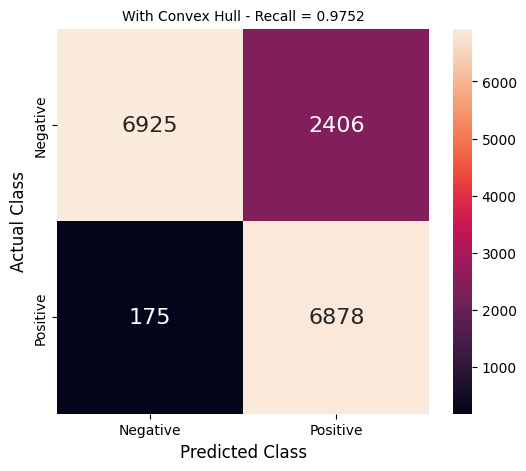

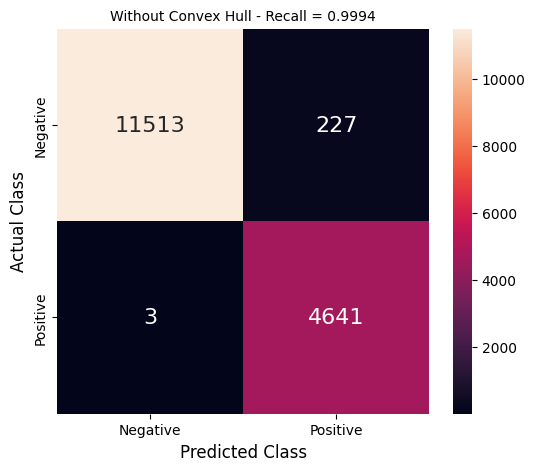

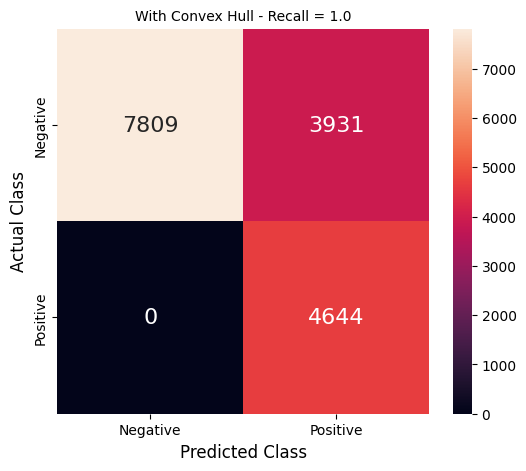

In [21]:
cm_ch0 = confusion_matrix(masks_flatten[argmin_recall_unet], masks_unet_ch0_flatten[argmin_recall_unet])
cm_ch1 = confusion_matrix(masks_flatten[argmin_recall_unet], masks_unet_ch1_flatten[argmin_recall_unet])

plt.figure(figsize=(6,5))
sns.heatmap(cm_ch0, annot=True, annot_kws={"size": 16}, fmt='d', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.title('Without Convex Hull - Recall = {}'.format(round(min_recall_unet, 4)), fontsize=10)
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(cm_ch1, annot=True, annot_kws={"size": 16}, fmt='d', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.title('With Convex Hull - Recall = {}'.format(round(new_min_recall, 4)), fontsize=10)
plt.show()

cm_ch0 = confusion_matrix(masks_flatten[argmax_recall_unet], masks_unet_ch0_flatten[argmax_recall_unet])
cm_ch1 = confusion_matrix(masks_flatten[argmax_recall_unet], masks_unet_ch1_flatten[argmax_recall_unet])

plt.figure(figsize=(6,5))
sns.heatmap(cm_ch0, annot=True, annot_kws={"size": 16}, fmt='d', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.title('Without Convex Hull - Recall = {}'.format(round(max_recall_unet, 4)), fontsize=10)
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(cm_ch1, annot=True, annot_kws={"size": 16}, fmt='d', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.title('With Convex Hull - Recall = {}'.format(round(new_max_recall, 4)), fontsize=10)
plt.show()

In [22]:
# masks_flatten_flatten = masks_flatten.reshape(-1)
# masks_unet_ch0_flatten_flatten = masks_unet_ch0_flatten.reshape(-1)
# masks_unet_ch1_flatten_flatten = masks_unet_ch1_flatten.reshape(-1)

# print(np.shape(masks_flatten_flatten))
# print(np.shape(masks_unet_ch0_flatten_flatten))
# print(np.shape(masks_unet_ch1_flatten_flatten))

In [23]:
# cm_unet_ch0 = confusion_matrix(masks_flatten_flatten, masks_unet_ch0_flatten_flatten)
# cm_unet_ch1 = confusion_matrix(masks_flatten_flatten, masks_unet_ch1_flatten_flatten)

# sns.heatmap(cm_unet_ch0, annot=True, fmt='d', xticklabels=['Positive', 'Negative'], yticklabels=['Positive', 'Negative'])
# plt.ylabel('Prediction', fontsize=13)
# plt.xlabel('Actual', fontsize=13)
# plt.title('Confusion Matrix', fontsize=17)
# plt.show()

# **3. Without Convex Hull - Unet Variants**

## **3.1. Unet**

In [24]:
unet_ch0 = load_model('/kaggle/input/unet/keras/default/6/Unet.h5')
unet_ch0.summary()

history_train_dice_unet_ch0 = np.load('/kaggle/input/unet/keras/default/6/history_train_dice.npy')
history_train_iou_unet_ch0 = np.load('/kaggle/input/unet/keras/default/6/history_train_iou.npy')
history_train_loss_unet_ch0 = np.load('/kaggle/input/unet/keras/default/6/history_train_loss.npy')
history_val_dice_unet_ch0 = np.load('/kaggle/input/unet/keras/default/6/history_val_dice.npy')
history_val_iou_unet_ch0 = np.load('/kaggle/input/unet/keras/default/6/history_val_iou.npy')
history_val_loss_unet_ch0 = np.load('/kaggle/input/unet/keras/default/6/history_val_loss.npy')

Model: "unet_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 1)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down0_0 (Conv2D)     │ (None, 128, 128, 16)   │            160 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down0_0_activation   │ (None, 128, 128, 16)   │              0 │ unet_down0_0[0][0]     │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down0_1 (Conv2D)     │ (None, 128, 128, 16)   │          2,320 │ unet_down0_0_activati… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down0_1_activation   │ (None, 128, 128, 16)   │              0 │ unet_down0_1[0][0]     │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down1_encode_maxpool │ (None, 64, 64, 16)     │              0 │ unet_down0_1_activati… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down1_conv_0         │ (None, 64, 64, 32)     │          4,640 │ unet_down1_encode_max… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down1_conv_0_activa… │ (None, 64, 64, 32)     │              0 │ unet_down1_conv_0[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down1_conv_1         │ (None, 64, 64, 32)     │          9,248 │ unet_down1_conv_0_act… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down1_conv_1_activa… │ (None, 64, 64, 32)     │              0 │ unet_down1_conv_1[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down2_encode_maxpool │ (None, 32, 32, 32)     │              0 │ unet_down1_conv_1_act… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down2_conv_0         │ (None, 32, 32, 64)     │         18,496 │ unet_down2_encode_max… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down2_conv_0_activa… │ (None, 32, 32, 64)     │              0 │ unet_down2_conv_0[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ unet_down2_conv_1         │ (None, 32, 32, 64)     │         36,928 │ unet_down2_conv_0_act… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 2,158,419 (8.23 MB)

 Trainable params: 2,158,417 (8.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

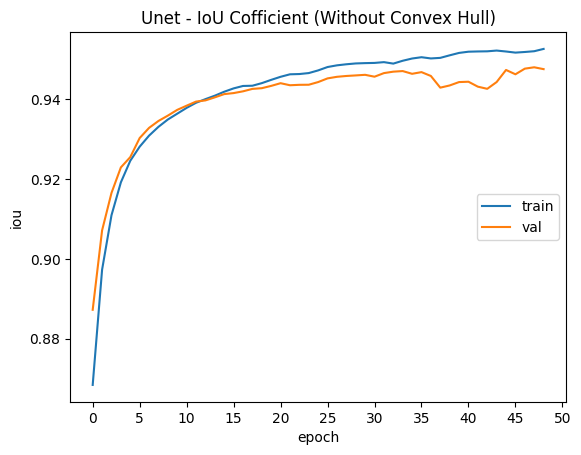

In [25]:
x = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
plt.plot(history_train_iou_unet_ch0[1:])
plt.plot(history_val_iou_unet_ch0[1:])
plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12) 
plt.xticks(x)
plt.title('Unet - IoU Cofficient (Without Convex Hull)')
plt.ylabel('iou')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='center right')
plt.show()
plt.close()

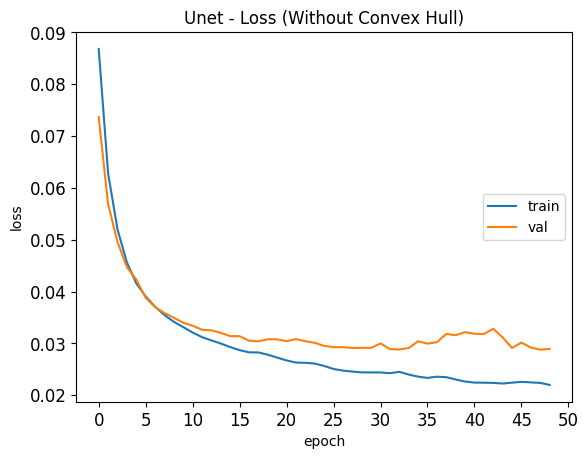

In [26]:
x = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
plt.plot(history_train_loss_unet_ch0[1:])
plt.plot(history_val_loss_unet_ch0[1:])
plt.xticks(x)
plt.title('Unet - Loss (Without Convex Hull)')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='center right')
plt.show()
plt.close()

## **3.2. Attention-Unet**

In [27]:
attunet_ch0 = load_model('/kaggle/input/unet/keras/default/8/Attention-Unet.h5')
attunet_ch0.summary()

history_train_dice_attunet_ch0 = np.load('/kaggle/input/unet/keras/default/8/history_train_dice.npy')
history_train_iou_attunet_ch0 = np.load('/kaggle/input/unet/keras/default/8/history_train_iou.npy')
history_train_loss_attunet_ch0 = np.load('/kaggle/input/unet/keras/default/8/history_train_loss.npy')
history_val_dice_attunet_ch0 = np.load('/kaggle/input/unet/keras/default/8/history_val_dice.npy')
history_val_iou_attunet_ch0 = np.load('/kaggle/input/unet/keras/default/8/history_val_iou.npy')
history_val_loss_attunet_ch0 = np.load('/kaggle/input/unet/keras/default/8/history_val_loss.npy')

Model: "attunet_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 1)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down0_0 (Conv2D)  │ (None, 128, 128, 16)   │            160 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down0_0_activati… │ (None, 128, 128, 16)   │              0 │ attunet_down0_0[0][0]  │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down0_1 (Conv2D)  │ (None, 128, 128, 16)   │          2,320 │ attunet_down0_0_activ… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down0_1_activati… │ (None, 128, 128, 16)   │              0 │ attunet_down0_1[0][0]  │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down1_encode_max… │ (None, 64, 64, 16)     │              0 │ attunet_down0_1_activ… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down1_conv_0      │ (None, 64, 64, 32)     │          4,640 │ attunet_down1_encode_… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down1_conv_0_act… │ (None, 64, 64, 32)     │              0 │ attunet_down1_conv_0[… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down1_conv_1      │ (None, 64, 64, 32)     │          9,248 │ attunet_down1_conv_0_… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down1_conv_1_act… │ (None, 64, 64, 32)     │              0 │ attunet_down1_conv_1[… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down2_encode_max… │ (None, 32, 32, 32)     │              0 │ attunet_down1_conv_1_… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down2_conv_0      │ (None, 32, 32, 64)     │         18,496 │ attunet_down2_encode_… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down2_conv_0_act… │ (None, 32, 32, 64)     │              0 │ attunet_down2_conv_0[… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attunet_down2_conv_1      │ (None, 32, 32, 64)     │         36,928 │ attunet_down2_conv_0_… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 1,995,343 (7.61 MB)

 Trainable params: 1,995,341 (7.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

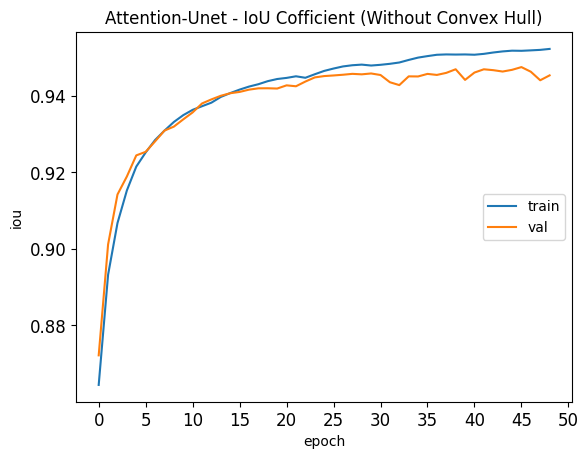

In [28]:
x = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
plt.plot(history_train_iou_attunet_ch0[1:])
plt.plot(history_val_iou_attunet_ch0[1:])
plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12) 
plt.xticks(x)
plt.title('Attention-Unet - IoU Cofficient (Without Convex Hull)')
plt.ylabel('iou')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='center right')
plt.show()
plt.close()

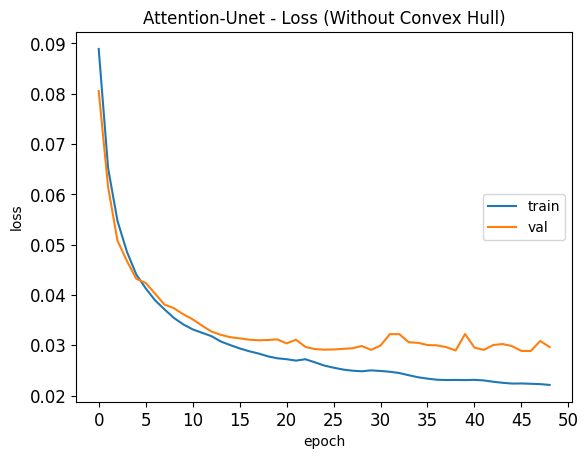

In [29]:
x = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
plt.plot(history_train_loss_attunet_ch0[1:])
plt.plot(history_val_loss_attunet_ch0[1:])
plt.xticks(x)
plt.title('Attention-Unet - Loss (Without Convex Hull)')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='center right')
plt.show()
plt.close()

## **3.3. Unet++**

In [30]:
unetpp_ch0 = load_model('/kaggle/input/unet/keras/default/9/Unet++.h5')
unetpp_ch0.summary()

history_train_dice_unetpp_ch0 = np.load('/kaggle/input/unet/keras/default/9/history_train_dice.npy')
history_train_iou_unetpp_ch0 = np.load('/kaggle/input/unet/keras/default/9/history_train_iou.npy')
history_train_loss_unetpp_ch0 = np.load('/kaggle/input/unet/keras/default/9/history_train_loss.npy')
history_val_dice_unetpp_ch0 = np.load('/kaggle/input/unet/keras/default/9/history_val_dice.npy')
history_val_iou_unetpp_ch0 = np.load('/kaggle/input/unet/keras/default/9/history_val_iou.npy')
history_val_loss_unetpp_ch0 = np.load('/kaggle/input/unet/keras/default/9/history_val_loss.npy')

Model: "xnet_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 128, 128, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xnet_down0_0 (Conv2D)                │ (None, 128, 128, 16)        │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xnet_down0_0_activation (ReLU)       │ (None, 128, 128, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xnet_down0_1 (Conv2D)                │ (None, 128, 128, 16)        │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xnet_down0_1_activation (ReLU)       │ (None, 128, 128, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xnet_down1_encode_maxpool            │ (None, 64, 64, 16)          │               0 │
│ (MaxPooling2D)                       │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xnet_down1_conv_0 (Conv2D)           │ (None, 64, 64, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xnet_down1_conv_0_activation (ReLU)  │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xnet_down1_conv_1 (Conv2D)           │ (None, 64, 64, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xnet_down1_conv_1_activation (ReLU)  │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xnet_down2_encode_maxpool            │ (None, 32, 32, 32)          │               0 │
│ (MaxPooling2D)                       │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xnet_down2_conv_0 (Conv2D)           │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xnet_down2_conv_0_activation (ReLU)  │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xnet_down2_conv_1 (Conv2D)           │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xnet_down2_conv_1_activation (ReLU)  │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xnet_down3_encode_maxpool            │ (None, 16, 16, 64)          │               0 │
│ (MaxPooling2D)                       │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xnet_down3_conv_0 (Conv2D)           │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xnet_down3_conv_0_activation (ReLU)  │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xnet_down3_conv_1 (Conv2D)           │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xnet_down3_conv_1_activation (ReLU)  │ (None, 16, 16, 128)         │              

 Total params: 1,962,579 (7.49 MB)

 Trainable params: 1,962,577 (7.49 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

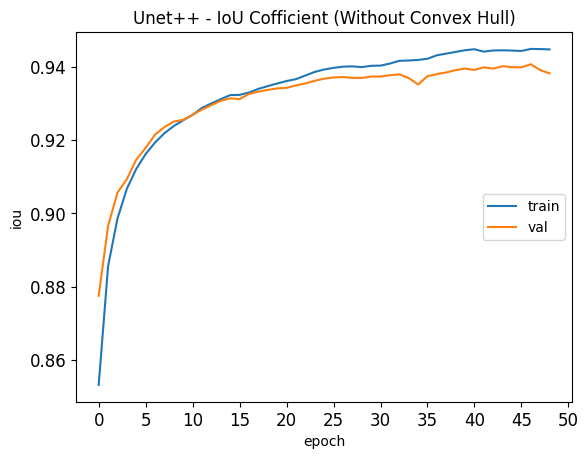

In [31]:
x = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
plt.plot(history_train_iou_unetpp_ch0[1:])
plt.plot(history_val_iou_unetpp_ch0[1:])
plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12) 
plt.xticks(x)
plt.title('Unet++ - IoU Cofficient (Without Convex Hull)')
plt.ylabel('iou')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='center right')
plt.show()
plt.close()

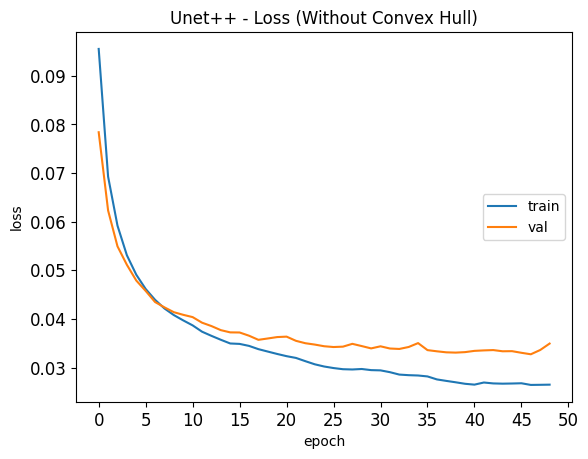

In [32]:
x = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
plt.plot(history_train_loss_unetpp_ch0[1:])
plt.plot(history_val_loss_unetpp_ch0[1:])
plt.xticks(x)
plt.title('Unet++ - Loss (Without Convex Hull)')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='center right')
plt.show()
plt.close()

## **3.4. R2Unet**

In [33]:
r2unet_ch0 = load_model('/kaggle/input/unet/keras/default/14/R2Unet.h5')
r2unet_ch0.summary()

history_train_dice_r2unet_ch0 = np.load('/kaggle/input/unet/keras/default/14/history_train_dice.npy')
history_train_iou_r2unet_ch0 = np.load('/kaggle/input/unet/keras/default/14/history_train_iou.npy')
history_train_loss_r2unet_ch0 = np.load('/kaggle/input/unet/keras/default/14/history_train_loss.npy')
history_val_dice_r2unet_ch0 = np.load('/kaggle/input/unet/keras/default/14/history_val_dice.npy')
history_val_iou_r2unet_ch0 = np.load('/kaggle/input/unet/keras/default/14/history_val_iou.npy')
history_val_loss_r2unet_ch0 = np.load('/kaggle/input/unet/keras/default/14/history_val_loss.npy')

Model: "r2_unet_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ r2_unet_input             │ (None, 128, 128, 1)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ r2_unet_down0_conv        │ (None, 128, 128, 16)   │             32 │ r2_unet_input[0][0]    │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ r2_unet_down0_conv0       │ (None, 128, 128, 16)   │          2,320 │ r2_unet_down0_conv[0]… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ r2_unet_down0_activation0 │ (None, 128, 128, 16)   │              0 │ r2_unet_down0_conv0[0… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ r2_unet_down0_add0_0      │ (None, 128, 128, 16)   │              0 │ r2_unet_down0_activat… │
│ (Add)                     │                        │                │ r2_unet_down0_conv[0]… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ r2_unet_down0_conv0_0     │ (None, 128, 128, 16)   │          2,320 │ r2_unet_down0_add0_0[… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ r2_unet_down0_activation… │ (None, 128, 128, 16)   │              0 │ r2_unet_down0_conv0_0… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ r2_unet_down0_add0_1      │ (None, 128, 128, 16)   │              0 │ r2_unet_down0_activat… │
│ (Add)                     │                        │                │ r2_unet_down0_conv[0]… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ r2_unet_down0_conv0_1     │ (None, 128, 128, 16)   │          2,320 │ r2_unet_down0_add0_1[… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ r2_unet_down0_activation… │ (None, 128, 128, 16)   │              0 │ r2_unet_down0_conv0_1… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ r2_unet_down0_conv1       │ (None, 128, 128, 16)   │          2,320 │ r2_unet_down0_activat… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ r2_unet_down0_activation1 │ (None, 128, 128, 16)   │              0 │ r2_unet_down0_conv1[0… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ r2_unet_down0_add1_0      │ (None, 128, 128, 16)   │              0 │ r2_unet_down0_activat… │
│ (Add)                     │                        │                │ r2_unet_down0_activat… │
├──────────────────────

 Total params: 6,373,171 (24.31 MB)

 Trainable params: 6,373,169 (24.31 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

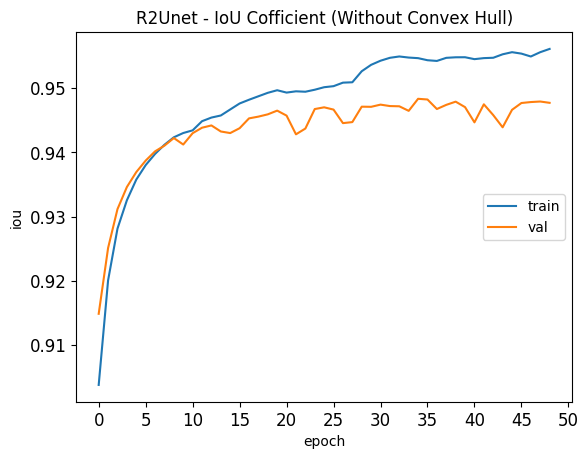

In [34]:
x = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
plt.plot(history_train_iou_r2unet_ch0[1:])
plt.plot(history_val_iou_r2unet_ch0[1:])
plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12) 
plt.xticks(x)
plt.title('R2Unet - IoU Cofficient (Without Convex Hull)')
plt.ylabel('iou')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='center right')
plt.show()
plt.close()

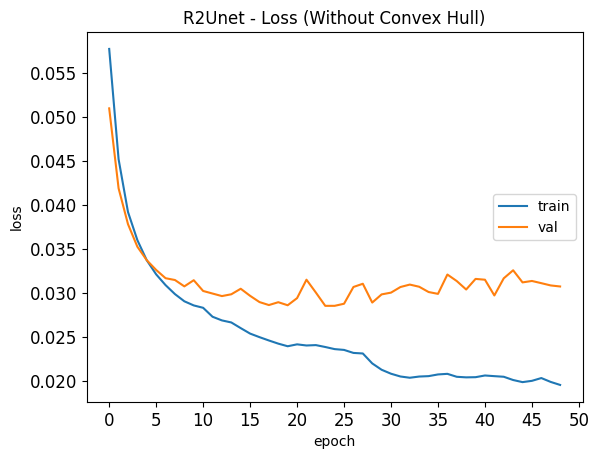

In [35]:
x = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
plt.plot(history_train_loss_r2unet_ch0[1:])
plt.plot(history_val_loss_r2unet_ch0[1:])
plt.xticks(x)
plt.title('R2Unet - Loss (Without Convex Hull)')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='center right')
plt.show()
plt.close()

## **3.6. Performance of Unet Variants**

In [36]:
masks_unet_ch0 = predict_mask(unet_ch0, cxrs_ch0)
masks_attunet_ch0 = predict_mask(attunet_ch0, cxrs_ch0)
masks_unetpp_ch0 = predict_mask(unetpp_ch0, cxrs_ch0)
masks_r2unet_ch0 = predict_mask(r2unet_ch0, cxrs_ch0)

print(np.shape(masks_unet_ch0))
print(np.shape(masks_attunet_ch0))
print(np.shape(masks_unetpp_ch0))
print(np.shape(masks_r2unet_ch0))

sz = np.shape(masks_ch0)[0]
masks_flatten = masks_ch0.reshape(sz, -1)
masks_unet_ch0_flatten = (masks_unet_ch0 >= 0.5).reshape(sz, -1)
masks_attunet_ch0_flatten = (masks_attunet_ch0 >= 0.5).reshape(sz, -1)
masks_unetpp_ch0_flatten = (masks_unetpp_ch0 >= 0.5).reshape(sz, -1)
masks_r2unet_ch0_flatten = (masks_r2unet_ch0 >= 0.5).reshape(sz, -1)

print(np.shape(masks_unet_ch0_flatten))
print(np.shape(masks_attunet_ch0_flatten))
print(np.shape(masks_unetpp_ch0_flatten))
print(np.shape(masks_r2unet_ch0_flatten))

22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 989ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 924ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 852ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step
(704, 128, 128, 1)
(704, 128, 128, 1)
(704, 128, 128, 1)
(704, 128, 128, 1)
(704, 16384)
(704, 16384)
(704, 16384)
(704, 16384)


In [37]:
dice_unet_ch0 = round(dice_coef(masks_ch0, masks_unet_ch0), 4)
iou_unet_ch0 = round(iou_coef(masks_ch0, masks_unet_ch0), 4)
loss_unet_ch0 = round(bce_loss(masks_ch0, masks_unet_ch0), 4)
recall_unet_ch0 = round(average_recall(masks_flatten, masks_unet_ch0_flatten), 4)
print('WITHOUT CONVEX HULL\n')
print('Unet:')
print('   dice = {}'.format(dice_unet_ch0))
print('   iou = {}'.format(iou_unet_ch0))
print('   loss = {}'.format(loss_unet_ch0))
print('   recall = {}'.format(recall_unet_ch0))

dice_attunet_ch0 = round(dice_coef(masks_ch0, masks_attunet_ch0), 4)
iou_attunet_ch0 = round(iou_coef(masks_ch0, masks_attunet_ch0), 4)
loss_attunet_ch0 = round(bce_loss(masks_ch0, masks_attunet_ch0), 4)
recall_attunet_ch0 = round(average_recall(masks_flatten, masks_attunet_ch0_flatten), 4)
print('\nAttention-Unet:')
print('   dice = {}'.format(dice_attunet_ch0))
print('   iou = {}'.format(iou_attunet_ch0))
print('   loss = {}'.format(loss_attunet_ch0))
print('   recall = {}'.format(recall_attunet_ch0))

dice_unetpp_ch0 = round(dice_coef(masks_ch0, masks_unetpp_ch0), 4)
iou_unetpp_ch0 = round(iou_coef(masks_ch0, masks_unetpp_ch0), 4)
loss_unetpp_ch0 = round(bce_loss(masks_ch0, masks_unetpp_ch0), 4)
recall_unetpp_ch0 = round(average_recall(masks_flatten, masks_unetpp_ch0_flatten), 4)
print('\nUnet++:')
print('   dice = {}'.format(dice_unetpp_ch0))
print('   iou = {}'.format(iou_unetpp_ch0))
print('   loss = {}'.format(loss_unetpp_ch0))
print('   recall = {}'.format(recall_unetpp_ch0))

dice_r2unet_ch0 = round(dice_coef(masks_ch0, masks_r2unet_ch0), 4)
iou_r2unet_ch0 = round(iou_coef(masks_ch0, masks_r2unet_ch0), 4)
loss_r2unet_ch0 = round(bce_loss(masks_ch0, masks_r2unet_ch0), 4)
recall_r2unet_ch0 = round(average_recall(masks_flatten, masks_r2unet_ch0_flatten), 4)
print('\nR2Unet:')
print('   dice = {}'.format(dice_r2unet_ch0))
print('   iou = {}'.format(iou_r2unet_ch0))
print('   loss = {}'.format(loss_r2unet_ch0))
print('   recall = {}'.format(recall_r2unet_ch0))

WITHOUT CONVEX HULL

Unet:
   dice = 0.9626
   iou = 0.929
   loss = 0.0925
   recall = 0.9625

Attention-Unet:
   dice = 0.9626
   iou = 0.9291
   loss = 0.0942
   recall = 0.959

Unet++:
   dice = 0.9573
   iou = 0.9191
   loss = 0.0974
   recall = 0.9686

R2Unet:
   dice = 0.9631
   iou = 0.9301
   loss = 0.1002
   recall = 0.9606


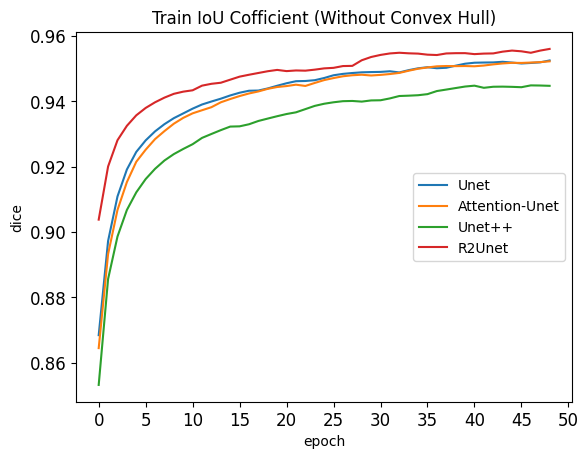

In [38]:
x = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
plt.plot(history_train_iou_unet_ch0[1:])
plt.plot(history_train_iou_attunet_ch0[1:])
plt.plot(history_train_iou_unetpp_ch0[1:])
plt.plot(history_train_iou_r2unet_ch0[1:])
plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12) 
plt.xticks(x)
plt.title('Train IoU Cofficient (Without Convex Hull)')
plt.ylabel('dice')
plt.xlabel('epoch')
plt.legend(['Unet', 'Attention-Unet', 'Unet++', 'R2Unet'], loc='center right')
plt.show()
plt.close()

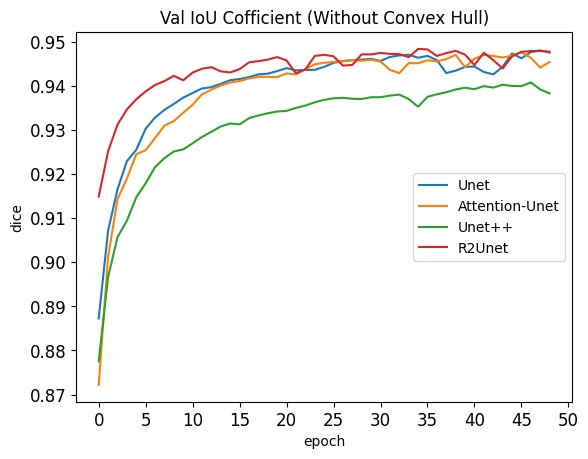

In [39]:
x = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
plt.plot(history_val_iou_unet_ch0[1:])
plt.plot(history_val_iou_attunet_ch0[1:])
plt.plot(history_val_iou_unetpp_ch0[1:])
plt.plot(history_val_iou_r2unet_ch0[1:])
plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12) 
plt.xticks(x)
plt.title('Val IoU Cofficient (Without Convex Hull)')
plt.ylabel('dice')
plt.xlabel('epoch')
plt.legend(['Unet', 'Attention-Unet', 'Unet++', 'R2Unet'], loc='center right')
plt.show()
plt.close()

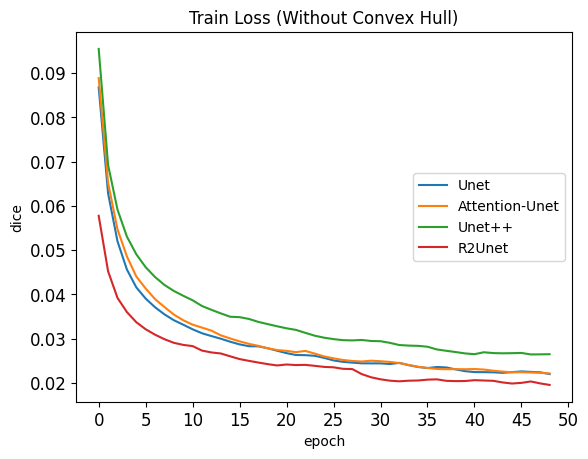

In [40]:
x = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
plt.plot(history_train_loss_unet_ch0[1:])
plt.plot(history_train_loss_attunet_ch0[1:])
plt.plot(history_train_loss_unetpp_ch0[1:])
plt.plot(history_train_loss_r2unet_ch0[1:])
plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12) 
plt.xticks(x)
plt.title('Train Loss (Without Convex Hull)')
plt.ylabel('dice')
plt.xlabel('epoch')
plt.legend(['Unet', 'Attention-Unet', 'Unet++', 'R2Unet'], loc='center right')
plt.show()
plt.close()

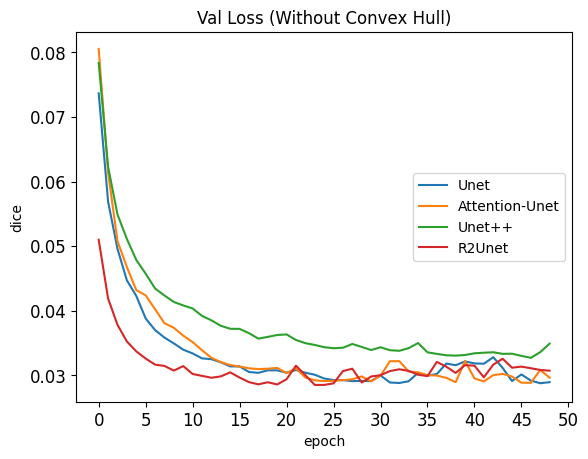

In [41]:
x = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
plt.plot(history_val_loss_unet_ch0[1:])
plt.plot(history_val_loss_attunet_ch0[1:])
plt.plot(history_val_loss_unetpp_ch0[1:])
plt.plot(history_val_loss_r2unet_ch0[1:])
plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12) 
plt.xticks(x)
plt.title('Val Loss (Without Convex Hull)')
plt.ylabel('dice')
plt.xlabel('epoch')
plt.legend(['Unet', 'Attention-Unet', 'Unet++', 'R2Unet'], loc='center right')
plt.show()
plt.close()

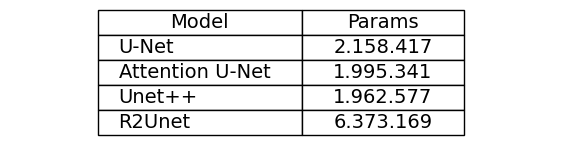

In [42]:
models = ['U-Net', 'Attention U-Net', 'Unet++', 'R2Unet']
params = [unet_ch0.count_params(), attunet_ch0.count_params(), unetpp_ch0.count_params(), r2unet_ch0.count_params()]
formatted_params = [format(p, ',').replace(',', '.') for p in params]

df = pd.DataFrame({'Model': models, 'Params': formatted_params})

fig, ax = plt.subplots(figsize=(7, 1))
ax.axis("tight")
ax.axis("off")

table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc="center", loc="center", colWidths=[0.25, 0.2, 0.2, 0.2, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.5, 1.5)

for (i, j), cell in table._cells.items():
    if i == 0: 
        cell.set_text_props(ha="center")
    elif j == 0:
        cell.set_text_props(ha="left")
            
plt.show()

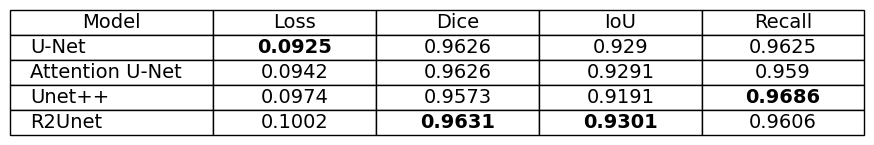

In [43]:
models = ['U-Net', 'Attention U-Net', 'Unet++', 'R2Unet']
loss = [loss_unet_ch0, loss_attunet_ch0, loss_unetpp_ch0, loss_r2unet_ch0]
dice = [dice_unet_ch0, dice_attunet_ch0, dice_unetpp_ch0, dice_r2unet_ch0]
iou = [iou_unet_ch0, iou_attunet_ch0, iou_unetpp_ch0, iou_r2unet_ch0]
recall = [recall_unet_ch0, recall_attunet_ch0, recall_unetpp_ch0, recall_r2unet_ch0]

df = pd.DataFrame({'Model': models, 'Loss': loss, 'Dice': dice, 'IoU': iou, 'Recall': recall})

min_loss = min(loss)
max_dice = max(dice)
max_iou = max(iou)
max_recall = max(recall)

fig, ax = plt.subplots(figsize=(7, 1))
ax.axis("tight")
ax.axis("off")

table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc="center", loc="center", colWidths=[0.25, 0.2, 0.2, 0.2, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.5, 1.5)

for (i, j), cell in table._cells.items():
    if i == 0: 
        cell.set_text_props(ha="center")
    elif j == 0:
        cell.set_text_props(ha="left")
    elif j == 1:
        cell.set_text_props(ha="center")
        if float(cell.get_text().get_text()) == min_loss:
            cell.set_text_props(weight="bold", color="black")
    elif j == 2:
        cell.set_text_props(ha="center")
        if float(cell.get_text().get_text()) == max_dice:
            cell.set_text_props(weight="bold", color="black")
    elif j == 3:
        cell.set_text_props(ha="center")
        if float(cell.get_text().get_text()) == max_iou:
            cell.set_text_props(weight="bold", color="black")
    elif j == 4:
        cell.set_text_props(ha="center")
        if float(cell.get_text().get_text()) == max_recall:
            cell.set_text_props(weight="bold", color="black")
            
plt.show()